Importing pandas and matplotlib

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

Reading the source data file: SSF (comma-separated-values) and displaying it

In [2]:
df=pd.read_csv('SSF.csv')
df

,Date,Month,Sales
0,Jan-17,1,60000
1,Feb-17,2,30000
2,Mar-17,3,40000
3,Apr-17,4,40000
4,May-17,5,35000
5,Jun-17,6,35000
6,Jul-17,7,75000
7,Aug-17,8,80000
8,Sep-17,9,65000
9,Oct-17,10,34000


Plotting the observations over time

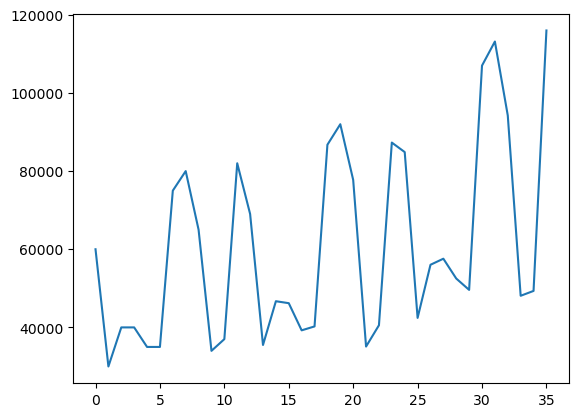

In [3]:
plt.plot(df.index, df.Sales)

Importing stats and obtaining descriptive statistics

In [4]:
from scipy import stats

slope, intercept, r_value, p_value, std_error=stats.linregress(df.index,df['Sales'])
print ('intercept =', intercept, '     slope =', slope, '     p_value =', p_value)

intercept = 42430.47147147148      slope = 1036.0555984555983      p_value = 0.007420222270398979


There is a positive slope, and there appears to be repeating patterns.

Creating a regression model, assuming linearity.
We are based on the equation:

Sales(m)=Origin+Trend(m)+Seasonality(m)+Error(m)

That means that we will decompose the series to separate its comonents: trend, seasonality, and error.

A new column called Reg will be created to contain the pure trend values. Another column, R1, will contain the residuals (seasonality + error), after substracting the trend and origin from Sales.

In [5]:
def create_Reg_col(row,intercept,slope):
    return float(intercept)+float(row['Month'])*slope

df['Reg']=df.apply(create_Reg_col, args=(intercept, slope), axis="columns")
df['R1']= df['Sales']-df['Reg']
# the following style is to eliminate decimals and make it look cleaner. Otherwise, just df will work and show decimals
df.style.format({
    'Sales': '{:,.0f}'.format,
    'Reg': '{:.0f}'.format,
    'R1': '{:.0f}'.format})

,Date,Month,Sales,Reg,R1
0,Jan-17,1,"60,000",43467,16533
1,Feb-17,2,"30,000",44503,-14503
2,Mar-17,3,"40,000",45539,-5539
3,Apr-17,4,"40,000",46575,-6575
4,May-17,5,"35,000",47611,-12611
5,Jun-17,6,"35,000",48647,-13647
6,Jul-17,7,"75,000",49683,25317
7,Aug-17,8,"80,000",50719,29281
8,Sep-17,9,"65,000",51755,13245
9,Oct-17,10,"34,000",52791,-18791


Plotting the trend

Text(0.5, 0, 'Month')

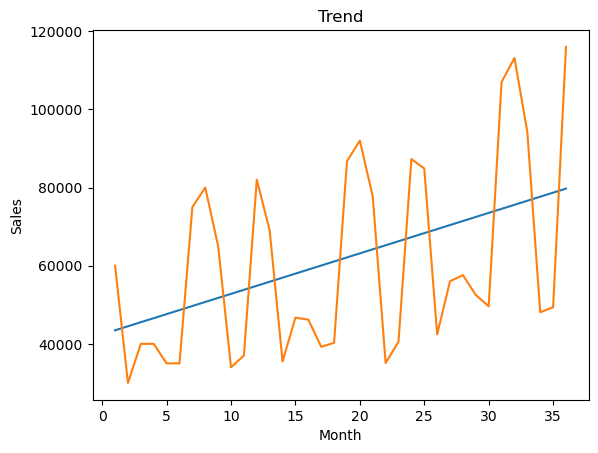

In [6]:
plt.plot(df.Month,df.Reg)
plt.plot(df.Month,df.Sales)
plt.title('Trend')
plt.ylabel('Sales')
plt.xlabel('Month')

Plotting the cyclicality. At first sight, there seems to be a repeating pattern every 12 months. Therefore the cyclicality is seasonal.

Text(0.5, 0, 'Month')

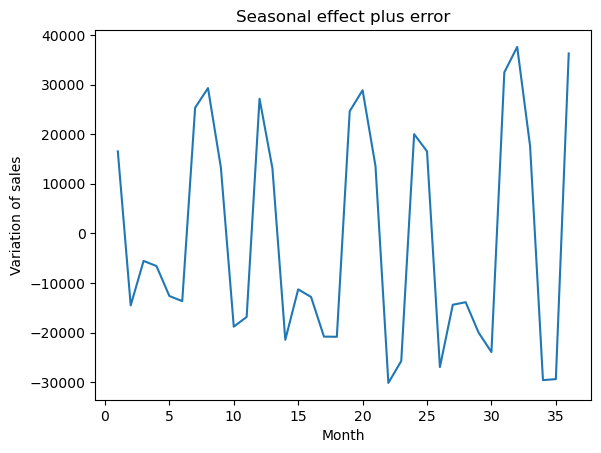

In [7]:
plt.plot(df.Month,df.R1)
plt.title('Seasonal effect plus error')
plt.ylabel('Variation of sales')
plt.xlabel('Month')

Using autocorrelation to determine the right cyclicality

In [8]:
for i in range(int(len(df.index)/2)):
    print ('autocorrelation, lag=', i,':',df.R1.autocorr(lag=i))

autocorrelation, lag= 0 : 1.0
autocorrelation, lag= 1 : 0.2185144481417999
autocorrelation, lag= 2 : -0.5095248840265
autocorrelation, lag= 3 : -0.3679923421930379
autocorrelation, lag= 4 : 0.09959740116109586
autocorrelation, lag= 5 : 0.10405834017043616
autocorrelation, lag= 6 : -0.08678814324619323
autocorrelation, lag= 7 : 0.08580888365752493
autocorrelation, lag= 8 : 0.1533916139135828
autocorrelation, lag= 9 : -0.3424189171873544
autocorrelation, lag= 10 : -0.5846594830317616
autocorrelation, lag= 11 : 0.27519975610840863
autocorrelation, lag= 12 : 0.9749487587123227
autocorrelation, lag= 13 : 0.21407633702142112
autocorrelation, lag= 14 : -0.5323139369765227
autocorrelation, lag= 15 : -0.4242130580672661
autocorrelation, lag= 16 : 0.03965631110329866
autocorrelation, lag= 17 : 0.09414202249423884


As you can see in the list above, the largest autocorrelation value is the one that corresponds to a lag of 12 months, confirming seasonality. Let's create a column with the values corresponding to a lag of 12 months and see how those values compare to the original (Sales vs lag12).

In [9]:
# Create a column with a lag of 12
import numpy as np
lag = 12
df['lag12']=np.NaN
for i in range(len(df['lag12']))[lag:]:
    df['lag12'].iloc[i]=df['Sales'].iloc[i-12]
df

C:\Users\danie\AppData\Local\Temp\ipykernel_17196\169253874.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['lag12'].iloc[i]=df['Sales'].iloc[i-12]


,Date,Month,Sales,Reg,R1,lag12
0,Jan-17,1,60000,43466.527070,16533.472930,NaN
1,Feb-17,2,30000,44502.582668,-14502.582668,NaN
2,Mar-17,3,40000,45538.638267,-5538.638267,NaN
3,Apr-17,4,40000,46574.693865,-6574.693865,NaN
4,May-17,5,35000,47610.749464,-12610.749464,NaN
5,Jun-17,6,35000,48646.805062,-13646.805062,NaN
6,Jul-17,7,75000,49682.860661,25317.139339,NaN
7,Aug-17,8,80000,50718.916259,29281.083741,NaN
8,Sep-17,9,65000,51754.971858,13245.028142,NaN
9,Oct-17,10,34000,52791.027456,-18791.027456,NaN


Now let's plot both columns and compare their shapes

Text(0.5, 0, 'Month')

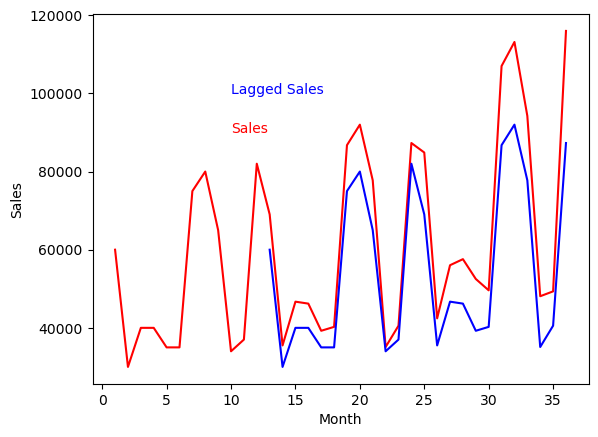

In [10]:
fig, ax = plt.subplots()
ax.plot(df.Month, df.Sales, c='r')
ax.plot(df.Month, df.lag12, c='b')
ax.text(10,90000,'Sales', color='r')
ax.text(10,100000, 'Lagged Sales', color='b')
ax.set_ylabel('Sales')
ax.set_xlabel('Month')

What happens if we separate each year?

               0             1             2
0   16533.472930  13130.805749  16538.138567
1  -14502.582668 -21435.249850 -26932.917031
2   -5538.638267 -11271.305448 -14373.972630
3   -6574.693865 -12807.361047 -13860.028228
4  -12610.749464 -20793.416645 -19968.083827
5  -13646.805062 -20829.472244 -23911.139425
6   25317.139339  24634.472158  32451.804976
7   29281.083741  28848.416559  37575.749378
8   13245.028142  13562.360961  17609.693779
9  -18791.027456 -30123.694637 -29563.361819
10 -16827.083054 -25709.750236 -29356.417417
11  27136.861347  20004.194166  36260.526984


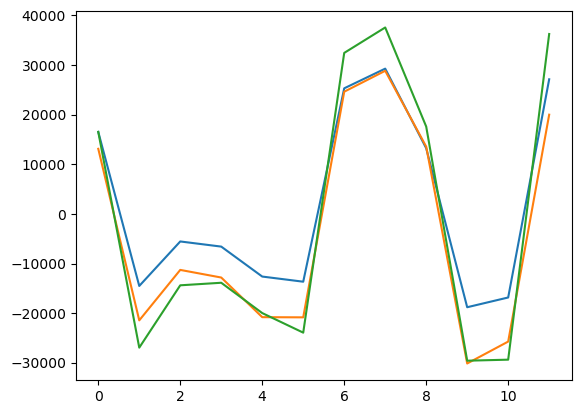

In [11]:
dfYear=pd.DataFrame()
cyclelen=12
for i in range (int(len(df.index)/cyclelen)):
    newdata=pd.DataFrame({i:df['R1'].iloc[i*cyclelen: (i+1)*cyclelen]})
    newdata.index = range (0,len(newdata))
    dfYear=pd.concat([dfYear,newdata],axis=1)
print(dfYear)
fig, ax = plt.subplots()
ax.plot(dfYear)

Calculate the average of the three cycles and see how it fits the rest. That will be our calculation of the seasonal component

               0             1             2           avg
0   16533.472930  13130.805749  16538.138567  15400.805749
1  -14502.582668 -21435.249850 -26932.917031 -20956.916517
2   -5538.638267 -11271.305448 -14373.972630 -10394.638782
3   -6574.693865 -12807.361047 -13860.028228 -11080.694380
4  -12610.749464 -20793.416645 -19968.083827 -17790.749979
5  -13646.805062 -20829.472244 -23911.139425 -19462.472244
6   25317.139339  24634.472158  32451.804976  27467.805491
7   29281.083741  28848.416559  37575.749378  31901.749893
8   13245.028142  13562.360961  17609.693779  14805.694294
9  -18791.027456 -30123.694637 -29563.361819 -26159.361304
10 -16827.083054 -25709.750236 -29356.417417 -23964.416903
11  27136.861347  20004.194166  36260.526984  27800.527499


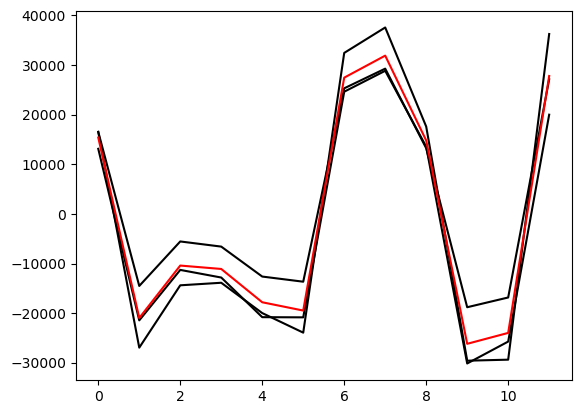

In [12]:
avg = []
for i in range(len(dfYear.index)):
    avg.append(dfYear.iloc[i].mean())

dfYear = pd.concat([dfYear,pd.DataFrame({'avg':avg})], axis=1)
print(dfYear)

fig,ax = plt.subplots()
c = 180
for col in dfYear.columns.values:
    if col == 'avg':
        ax.plot(dfYear[col], c = 'r')
    else:
        ax.plot(dfYear[col], c = 'k')

Now, let's calculate the final error (R2) by substracting the seasonality component from our first remainder (R1)

In [13]:
df['S'] = np.NaN
df['R2'] = np.NaN
df['Model'] = np.NaN
df['errorPerc'] = np.NaN
S = dfYear['avg'].tolist()
for i in df.index:
    df.loc[i,'S'] = S[i%cyclelen]
    df.loc[i,'R2'] = df.loc[i,'R1'] - df.loc[i,'S']
    df.loc[i,'Model'] = df.loc[i,'Reg'] + df.loc[i,'S']
    df.loc[i,'errorPerc'] = 100*df.loc[i,'R2'] / df.loc[i,'Sales']
df.style.format({
    'Sales': '{:,.0f}'.format,
    'Reg': '{:,.0f}'.format,
    'R1': '{:,.0f}'.format,
    'S': '{:,.0f}'.format,
    'R2': '{:,.0f}'.format,
    'Model':'{:,.0f}'.format,
    'errorPerc': '{:.2f}%'.format
})

,Date,Month,Sales,Reg,R1,lag12,S,R2,Model,errorPerc
0,Jan-17,1,"60,000","43,467","16,533",nan,"15,401","1,133","58,867",1.89%
1,Feb-17,2,"30,000","44,503","-14,503",nan,"-20,957","6,454","23,546",21.51%
2,Mar-17,3,"40,000","45,539","-5,539",nan,"-10,395","4,856","35,144",12.14%
3,Apr-17,4,"40,000","46,575","-6,575",nan,"-11,081","4,506","35,494",11.27%
4,May-17,5,"35,000","47,611","-12,611",nan,"-17,791","5,180","29,820",14.80%
5,Jun-17,6,"35,000","48,647","-13,647",nan,"-19,462","5,816","29,184",16.62%
6,Jul-17,7,"75,000","49,683","25,317",nan,"27,468","-2,151","77,151",-2.87%
7,Aug-17,8,"80,000","50,719","29,281",nan,"31,902","-2,621","82,621",-3.28%
8,Sep-17,9,"65,000","51,755","13,245",nan,"14,806","-1,561","66,561",-2.40%
9,Oct-17,10,"34,000","52,791","-18,791",nan,"-26,159","7,368","26,632",21.67%


Let's take a look at our seasonality

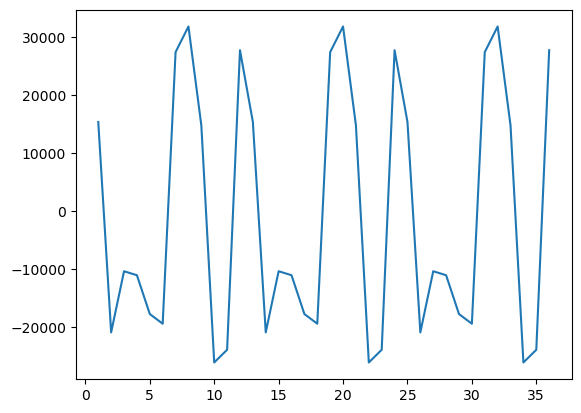

In [14]:
plt.plot(df.Month, df.S)

And let's see how well the model fits

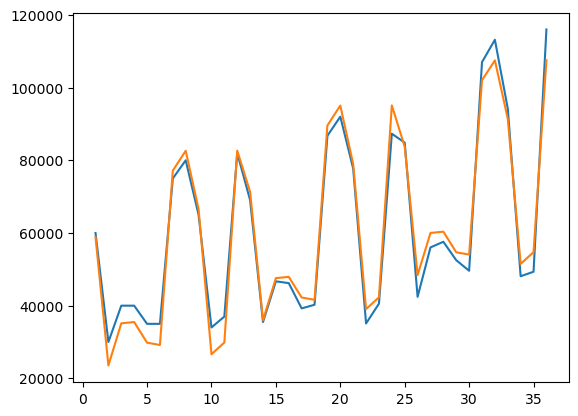

In [15]:
plt.plot(df.Month, df.Sales)
plt.plot(df.Month, df.Model)

Finally, we see the residuals (R2)

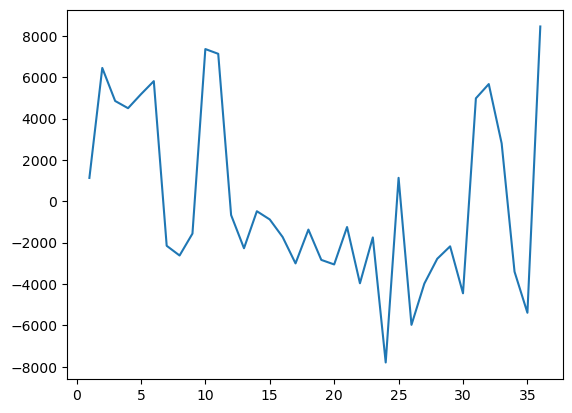

In [16]:
plt.plot(df.Month, df.R2)

And the percentage errors 

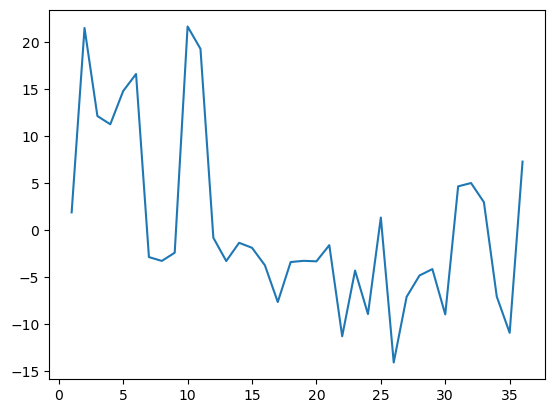

In [17]:
plt.plot(df.Month, df.errorPerc)